In [1]:
import sys
sys.path.append(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq")

from TCC.utils.constantes import *
import matplotlib.pyplot as plt

## STABLECOIN DOMINANCE

- Referente a share de mercado em porcentagem da stablecoin
- USDT e USDC (principais)

## Hipótese 1: Era Varejo (Pré-2020)
A Fricção Bancária e Irrelevância Sistémica. Neste período, o volume de Stablecoins era uma fração ínfima do mercado total. O par de negociação dominante era BTC/USD (Fiat Real). Hipotetiza-se que a variação na dominância das stablecoins tinha baixo poder preditivo sobre o preço do Bitcoin. O aumento de stablecoins refletia mais dificuldades de saque bancário (arbitragem e fricção regulatória) do que uma estratégia macro de alocação de portfólio ("Cash is King").

## Hipótese 2: Era Institucional (Pós-2020)
O Indicador de "Pólvora Seca" (Dry Powder) e Aversão ao Risco. Com a dolarização da infraestrutura cripto (DeFi e CEXs), a Stablecoin Dominance tornou-se a principal métrica de liquidez latente. Hipotetiza-se uma forte correlação negativa com o preço do Bitcoin.

Dominância Sobe (Aversão): Investidores vendem Bitcoin e Altcoins para buscar a segurança do Dólar digital (USDT/USDC). Isso sinaliza capitulação ou medo extremo, frequentemente marcando fundos de mercado (Bottoms).

Dominância Cai (Apetite): O capital que estava parado ("pólvora seca") é mobilizado para comprar ativos. Essa rotação de liquidez (Stable -> BTC) impulsiona o preço do Bitcoin, sinalizando entrada de fluxo comprador.

In [6]:
df_usdt_raw = pd.read_csv(rf"raw/201501_dominance_usdt.csv")
df_usdt_raw['Data_UTC'] = pd.to_datetime(df_usdt_raw['time'],unit='s', utc=True).dt.strftime("%Y-%m-%d")


df_usdt_raw = (pd.read_csv(rf"raw/201501_dominance_usdt.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'usdt_dominance'}) 

                        [['Data_UTC', 'usdt_dominance']] 
 
)
df_usdt_raw

df_usdt_log_ret =(
    df_periodo
        .merge(df_usdt_raw, how='left', on='Data_UTC')
        .assign(usdt_dominance = lambda df: df['usdt_dominance'].ffill())
        .assign(usdt_log_ret = lambda df: np.log(df['usdt_dominance']) - np.log(df['usdt_dominance'].shift(1)))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','usdt_dominance','usdt_log_ret']]

)
df_usdt_log_ret
# print_dataframe_info(df_usdt_log_ret, "USDT Price")

,Data_UTC,usdt_dominance,usdt_log_ret
4,2017-01-04,0.051866,-0.098469
5,2017-01-05,0.058812,0.125686
6,2017-01-06,0.066014,0.115518
7,2017-01-07,0.065095,-0.014020
8,2017-01-08,0.096968,0.398525
...,...,...,...
3131,2025-07-28,4.274753,0.017208
3132,2025-07-29,4.285907,0.002606
3133,2025-07-30,4.302326,0.003824
3134,2025-07-31,4.387686,0.019646


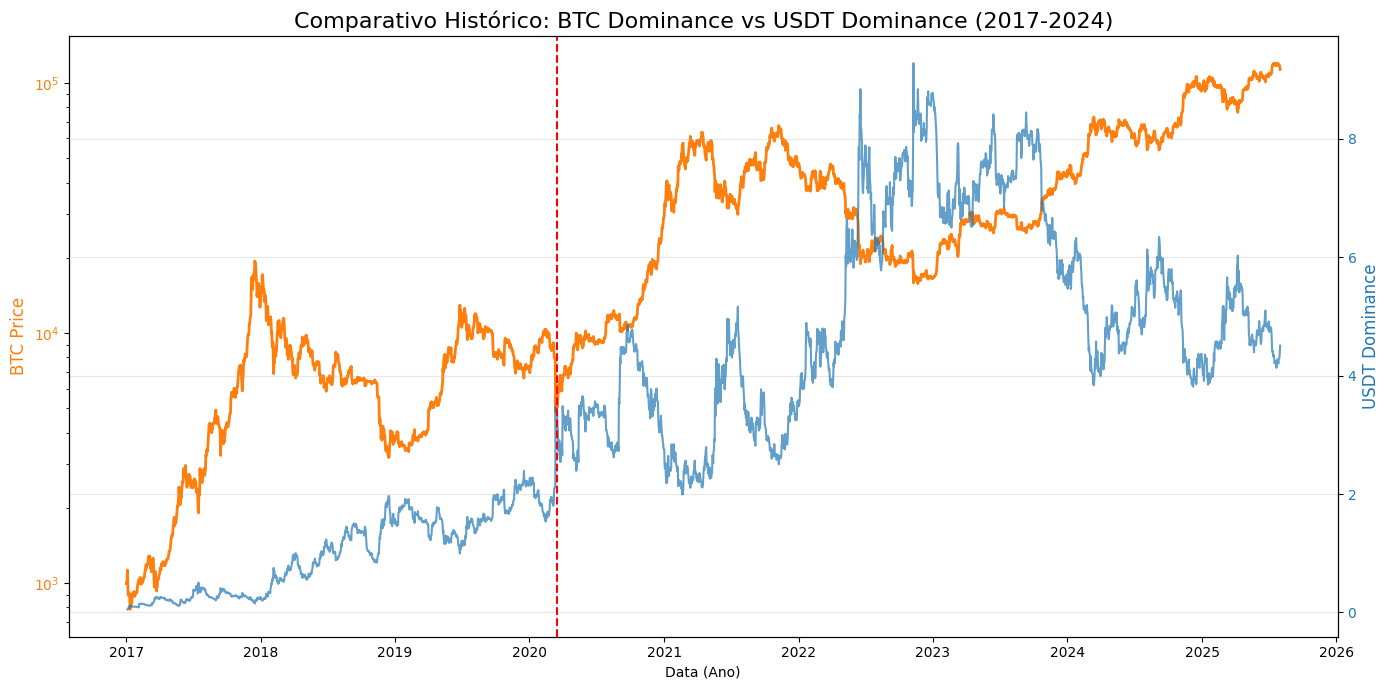

In [7]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('USDT Dominance', color=color, fontsize=12)
ax2.plot(df_usdt_log_ret['Data_UTC'], df_usdt_log_ret['usdt_dominance'], color=color, label='USDT Dominance', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs USDT Dominance (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## USDT

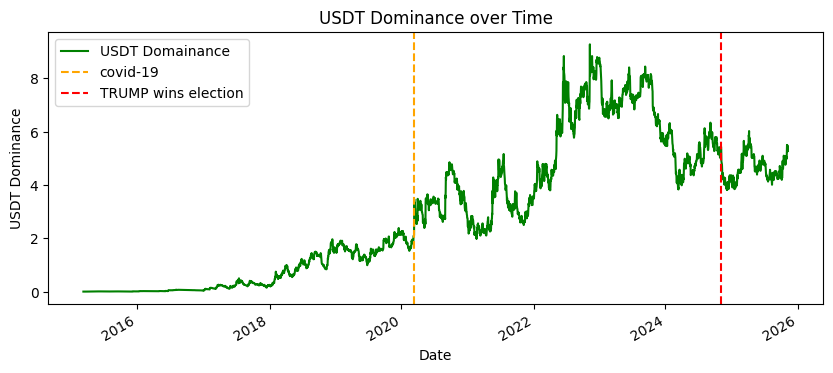

In [5]:
plt.figure(figsize=(10,4))
plt.plot(df_usdt['Data_UTC'], df_usdt['close_price'], label='USDT Domainance', color='green')
plt.xlabel('Date')
plt.ylabel('USDT Dominance')
plt.axvline(pd.to_datetime('2020-03-12'), color='orange', linestyle='--', label='covid-19')
plt.axvline(pd.to_datetime('2024-11-06'), color='red', linestyle='--', label='TRUMP wins election')
plt.title('USDT Dominance over Time')
plt.legend()
plt.gcf().autofmt_xdate()   # rotaciona e formata os labels de data
plt.show()


In [ ]:
df_usdc_raw = (pd.read_csv(rf"raw/201901_dominance_usdc.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'usdc_dominance'}) 
                        [['Data_UTC', 'usdc_dominance']] 
 
)
df_usdc_raw

df_usdc_log_ret =(
    df_periodo
        .merge(df_usdc_raw, how='left', on='Data_UTC')
        .assign(usdc_dominance = lambda df: df['usdc_dominance'].ffill())
        .assign(usdc_log_ret = lambda df: np.log(df['usdc_dominance']) - np.log(df['usdc_dominance'].shift(1)))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','usdc_dominance','usdc_log_ret']]

)
df_usdc_log_ret
# print_dataframe_info(df_usdc_log_ret, "USDC Price")

,Data_UTC,usdc_dominance,usdc_log_ret
4,2017-01-04,NaN,NaN
5,2017-01-05,NaN,NaN
6,2017-01-06,NaN,NaN
7,2017-01-07,NaN,NaN
8,2017-01-08,NaN,NaN
...,...,...,...
3131,2025-07-28,1.669537,0.011144
3132,2025-07-29,1.671676,0.001281
3133,2025-07-30,1.681906,0.006101
3134,2025-07-31,1.716013,0.020076


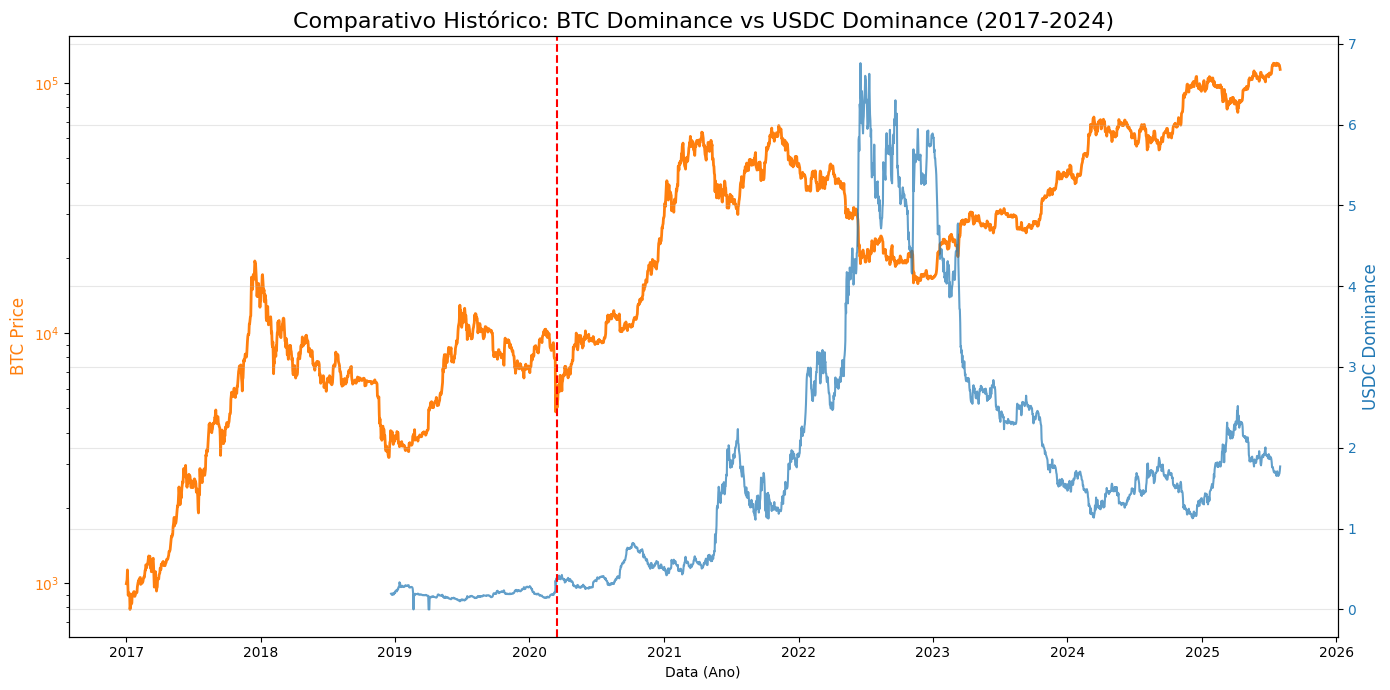

In [9]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('USDC Dominance', color=color, fontsize=12)
ax2.plot(df_usdc_log_ret['Data_UTC'], df_usdc_log_ret['usdc_dominance'], color=color, label='USDC Dominance', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs USDC Dominance (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## USDC

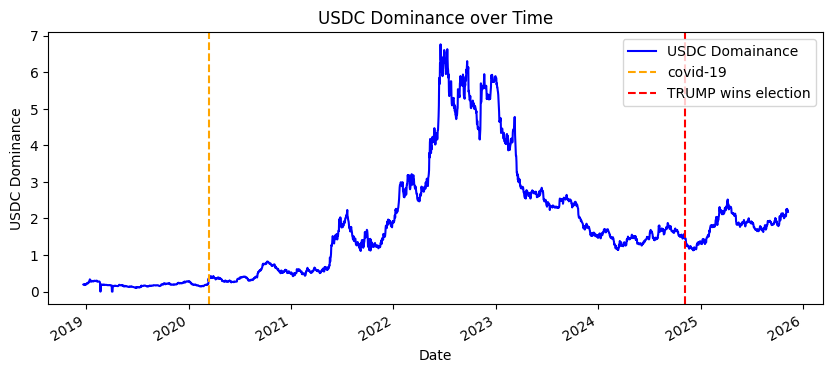

In [8]:
plt.figure(figsize=(10,4))
plt.plot(df_base['Data_UTC'], df_base['close_price'], label='USDC Domainance', color='blue')
plt.xlabel('Date')
plt.ylabel('USDC Dominance')
plt.axvline(pd.to_datetime('2020-03-12'), color='orange', linestyle='--', label='covid-19')
plt.axvline(pd.to_datetime('2024-11-06'), color='red', linestyle='--', label='TRUMP wins election')
plt.title('USDC Dominance over Time')
plt.legend()
plt.gcf().autofmt_xdate()   # rotaciona e formata os labels de data
plt.show()
